# Nowcasting rain maps from CML: the pipeline, faithful and corrected

The experiment behind the paper, as a sequence of calls: OpenMRG radar,
gauges and links -> per-link rain (physical, and a two-step RNN) -> IDW and
GMZ maps -> Transformer, GRU and POD-SINDy forecasts 15-60 min ahead ->
scores against gauges and radar.

`advanced_models_colab_v2.ipynb` stays the record of what the paper ran.
This notebook runs the same pipeline from `src/` (`config`, `data`, `maps`,
`forecasting`, `evaluation`, `pipeline`, `plots`), twice:

* **faithful** - the notebook's choices exactly
* **corrected** - four fixes: IDW distance in km instead of degrees, GMZ
  patched and registered to the radar grid correctly, pySTEPS aligned with
  the other models (see `config.py` for the table)

**This execution uses `NowcastConfig.smoke()`**: 9 days of training, 20
epochs for the estimation network, 5 for the forecasters, on a CPU. It shows
that every stage runs and which way each fix pushes. It does **not**
reproduce the paper's numbers or rank the models - that needs
`NowcastConfig()` (three months, the full budget, a GPU). pySTEPS is skipped
here: it does not build on this machine.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core import viz_style as vs
from config import NowcastConfig
import evaluation as ev
import pipeline
import plots

vs.use_style()

## Run both modes

Every stage is cached, keyed by the settings it depends on; the inputs are shared.

In [2]:
faithful = pipeline.run(NowcastConfig.smoke(faithful=True))
corrected = pipeline.run(NowcastConfig.smoke(faithful=False))
h = corrected["estimation"]["history"]
print(f"estimation RNN: best epoch {h['best_epoch']}, validation loss {min(h['val_loss']):.3f}")

Pysteps configuration file found at: /Users/drorjac/.pysteps/pystepsrc



/Users/drorjac/PycharmProjects/FieldSense/.venv/lib/python3.11/site-packages/pysteps/utils/cleansing.py:242: UserWarning: Singular matrix during outlier detection
  warnings.warn(f"{err} during outlier detection")


/Users/drorjac/PycharmProjects/FieldSense/.venv/lib/python3.11/site-packages/pysteps/utils/cleansing.py:242: UserWarning: Singular matrix during outlier detection
  warnings.warn(f"{err} during outlier detection")


estimation RNN: best epoch 15, validation loss 0.141


## Scores, corrected mode

Mean over the four horizons. `persistence_radar_one_step_late` is not a
model: it persists the frame the notebook's pySTEPS extrapolated from - one
step later than every other model sees. At 15 minutes that frame **is** the
truth: it scores HSS 1.00 and RMSE 0 below, which is what the paper's
pySTEPS was compared against at its first horizon. `cml_now_physical` is the
CML estimate *at* the target time, a reference rather than a forecast.

In [3]:
ev.ranking(corrected["vs_radar"]).round(3)

,RMSE,CC,HSS,F1
model,,,,
pysteps,0.431,0.657,0.722,0.742
persistence_radar_one_step_late,0.478,0.517,0.717,0.738
persistence_gauge,0.689,0.371,0.590,0.624
persistence_radar,0.660,0.310,0.583,0.614
persistence_cml,0.621,0.359,0.437,0.495
sindy_idw,0.655,0.354,0.421,0.482
gru_multi_idw,0.551,0.340,0.390,0.456
transformer_single_idw,0.516,0.424,0.390,0.456
gru_single_idw,0.537,0.335,0.387,0.453


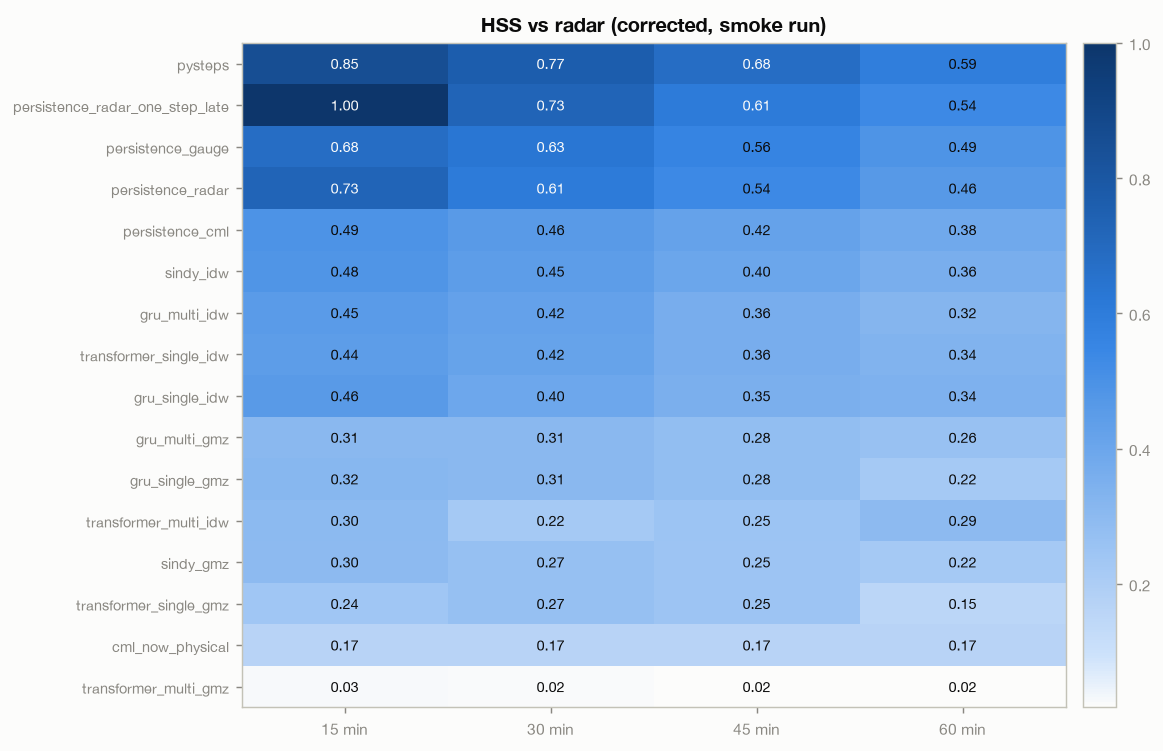

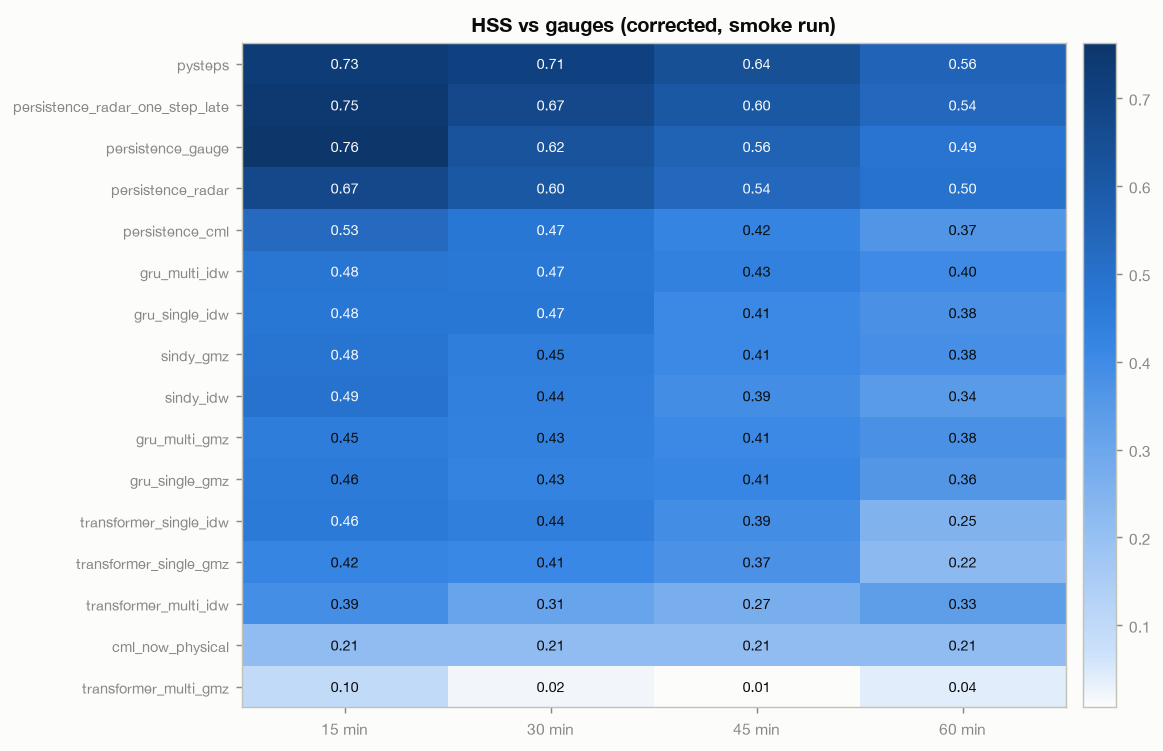

In [4]:
plots.skill_heatmap(corrected["vs_radar"], "HSS", title="HSS vs radar (corrected, smoke run)");
plots.skill_heatmap(corrected["vs_gauges"], "HSS", title="HSS vs gauges (corrected, smoke run)");

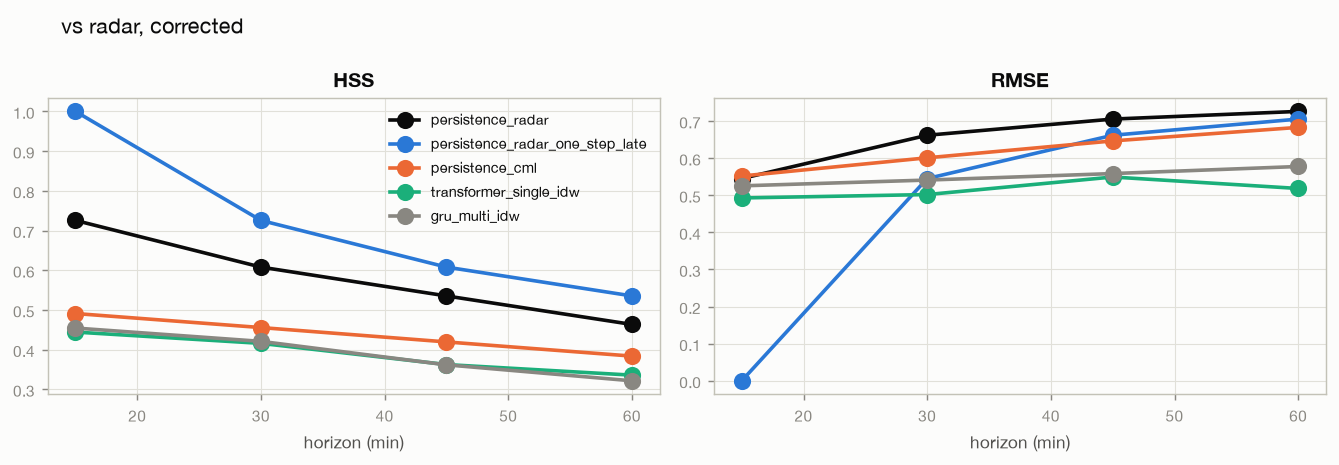

In [5]:
focus = ["persistence_radar", "persistence_radar_one_step_late", "persistence_cml",
         "transformer_single_idw", "gru_multi_idw"]
plots.skill_vs_horizon(corrected["vs_radar"], focus, title="vs radar, corrected");

## What the corrections change

HSS vs radar per model, faithful against corrected, same data and budget.

In [6]:
ev.compare(faithful["vs_radar"], corrected["vs_radar"]).round(3)

,faithful,corrected,change
model,,,
transformer_single_gmz,0.085,0.226,0.141
sindy_gmz,0.198,0.260,0.062
gru_multi_gmz,0.229,0.289,0.059
gru_single_gmz,0.236,0.281,0.046
pysteps,0.696,0.722,0.026
gru_single_idw,0.375,0.387,0.011
cml_now_physical,0.157,0.165,0.009
persistence_radar,0.583,0.583,0.000
persistence_radar_one_step_late,0.717,0.717,0.000


Four of the five GMZ-trained models gain (up to +0.14): both GMZ fixes act
on their input maps. One IDW-trained model, the multi-horizon Transformer,
loses 0.14. At this budget (5 epochs) the multi-horizon Transformer is
unstable - its GMZ twin scores near zero in both modes - so a single short
run cannot separate that swing from noise. The full run, with several seeds,
is what would settle it.

## One timestep, truth and forecasts (30 min ahead)

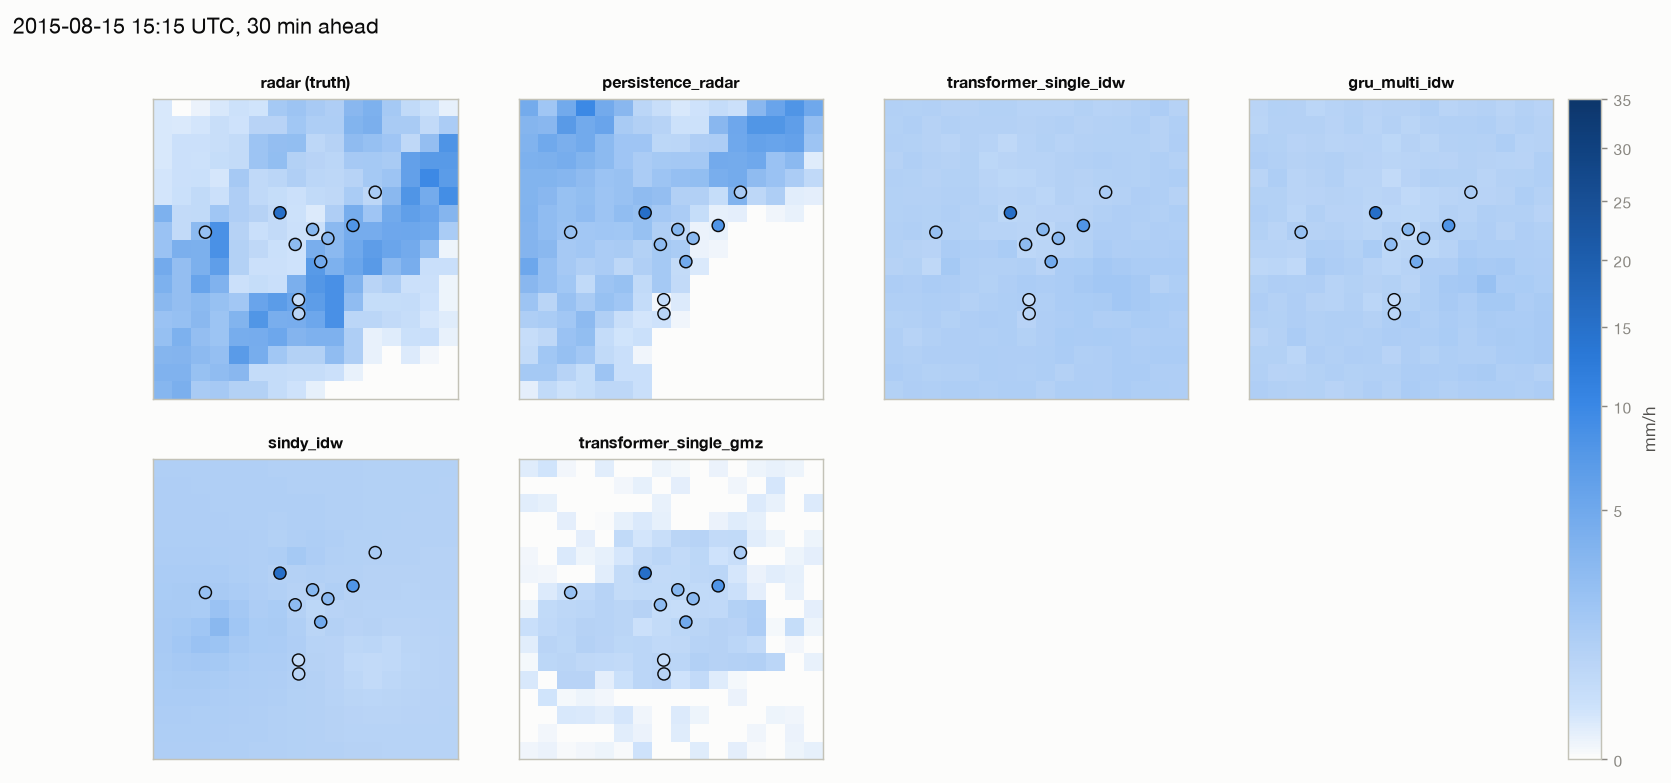

In [7]:
import numpy as np

cfg = NowcastConfig.smoke(faithful=False)
inp, fcs = corrected["inputs"], corrected["forecasts"]["forecasts"]
rad, gauges = inp["radar"], inp["gauges"]
lo, hi = cfg.split_index(rad["times"], "test")
h, lb = 2, cfg.lookback
i = int(np.argmax(rad["R"][lo + lb - 1 + h:hi].mean(axis=(1, 2))[:len(fcs["persistence_radar"][h])]))
t = lo + lb - 1 + h + i
frames = {"radar (truth)": rad["R"][t]}
frames.update({m: fcs[m][h][i] for m in ("persistence_radar", "transformer_single_idw",
                                           "gru_multi_idw", "sindy_idw", "transformer_single_gmz")})
plots.peak_maps(frames, rad["lon"], rad["lat"], inp["crop"],
                gauges=(gauges["lon"], gauges["lat"], gauges["R"].values[t]),
                title=f"{rad['times'][t]:%Y-%m-%d %H:%M} UTC, 30 min ahead");

## Running the real experiment

```python
full = pipeline.run(NowcastConfig(faithful=False))     # three months; hours on a GPU
```

The paper's hyper-parameters came from W&B sweeps in the original notebook;
`NowcastConfig` holds its defaults, and the sweeps' best configs can be passed
in (`transformer=...`, `gru=...`, `est_hparams=...`).